# **1. Data preprocessing**

Dataset info

General Overview
The dataset comprises 7,043 individual customer records from a telecommunications company, providing a comprehensive snapshot of consumer behavior and service usage. Each instance represents a unique customer profile, characterized by 21 distinct features ranging from demographic information to service-specific metrics and billing details. The data serves as a benchmark for binary classification tasks, specifically focused on predicting Customer Churn—the phenomenon where clients terminate their service agreements with the provider.

Data Integrity and Synthetic Missingness While the original dataset from the provided source  is largely complete and consistent, it does not inherently contain a sufficient volume of missing values to conduct a robust comparative analysis of imputation techniques. To address the core research objective of this project—evaluating the impact of data recovery on model performance—a synthetic missingness of 10% has been manually injected into the features. This deliberate modification transforms the "clean" dataset into a challenging environment for data engineering.
Comparative Imputation Framework The primary motivation for introducing these gaps is to create a controlled experimental setup to compare four distinct data recovery strategies.

Dataset Link: https://www.kaggle.com/datasets/cdeotte/s6e3-original-dataset/data

In [112]:
# wczytanie bibliotek
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [113]:
# wczytanie danych
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.head(10))

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
6  1452-KIOVK    Male              0      No        Yes      22          Yes   
7  6713-OKOMC  Female              0      No         No      10           No   
8  7892-POOKP  Female              0     Yes         No      28          Yes   
9  6388-TABGU    Male              0      No        Yes      62          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL        

In [114]:
# usunięcie kolumny z ID klienta - jest ono zawsze unikalne, może przeszkadzać w klasyfikacji
df.drop('customerID', axis=1, inplace=True)
print(df.head(10))

   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   
5  Female              0      No         No       8          Yes   
6    Male              0      No        Yes      22          Yes   
7  Female              0      No         No      10           No   
8  Female              0     Yes         No      28          Yes   
9    Male              0      No        Yes      62          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes

In [115]:
# wgląd w kolumny
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [116]:
#sprawdzenie błędów
print("Wrong data per column:")
print((df == -200).sum())

Wrong data per column:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [117]:
# sprawdzenie pustych rekordów
missing_data = df.isna().any().any()
print(f"Is missing data in the dataset: {missing_data}")
print(f"Missing data per column:")
print(df.isna().sum())

Is missing data in the dataset: False
Missing data per column:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [118]:
# sprawdzenie zduplikowanych danych
print(f"Duplicated data:")
print(df.duplicated().sum())

Duplicated data:
22


Creating missing data

We are randomly creating missing data from dataset to compare imputation methods, even for column which depends on values from other colums - to point out how each method will deal with this problem.

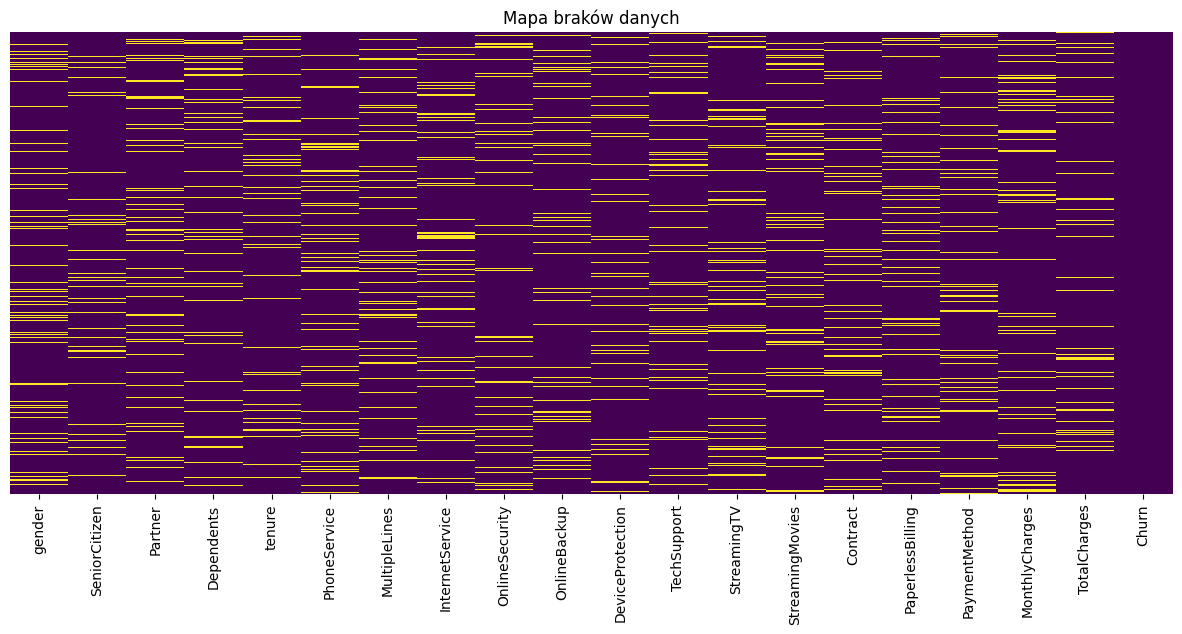

Procent braków w wybranych kolumnach:
gender             10.0
SeniorCitizen      10.0
Partner            10.0
Dependents         10.0
tenure             10.0
PhoneService       10.0
MultipleLines      10.0
InternetService    10.0
OnlineSecurity     10.0
OnlineBackup       10.0
dtype: float64
Weryfikacja braków po modyfikacji:
gender              704
SeniorCitizen       704
Partner             704
Dependents          704
tenure              704
PhoneService        704
MultipleLines       704
InternetService     704
OnlineSecurity      704
OnlineBackup        704
DeviceProtection    704
TechSupport         704
StreamingTV         704
StreamingMovies     704
Contract            704
PaperlessBilling    704
PaymentMethod       704
MonthlyCharges      704
TotalCharges        704
Churn                 0
dtype: int64
Braki w kolumnie Churn: 0


In [119]:
# sztuczne tworzenie braków w danych ze względu na ich kompletność - 10% danych

# kopia oryginalna
df_completed = df.copy()

# ziarno losowości
np.random.seed(8)
# wybór kolumn do utworzenia braków, pomijamy kolumnę churn do klasyfikacji
# wybieramy także kolumny zależne od siebie, głównie po to, aby pokazać różnice pomiędzy metodami imputacji danych
cols_to_corrupt = [col for col in df.columns if col != 'Churn']

# 10% braków w każdej z kolumn
for col in cols_to_corrupt:
    # losowe 10% indeksów dla każdej z kolumn
    n_missing = int(len(df) * 0.1)
    missing_indices = np.random.choice(df.index, n_missing, replace=False)
    df.loc[missing_indices, col] = np.nan

# mapa braków danych
plt.figure(figsize=(15, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa braków danych')
plt.show()

# podsumowanie procentowe i ilościowe brakujących rekordów dla wybranych kolumn
print("Procent braków w wybranych kolumnach:")
print(round((df.isnull().sum() / len(df) * 100), 2).head(10))
print("Weryfikacja braków po modyfikacji:")
print(df.isna().sum())
print(f"Braki w kolumnie Churn: {df['Churn'].isnull().sum()}")


In [120]:
# ponowne sprawdzenie zduplikowanych danych
print(f"Duplicated data:")
print(df.duplicated().sum())

Duplicated data:
0


In [121]:
# pobranie typów danych
df.info()

# enkodowanie nastąpi po imputacji danych, narazie niezbedne jest jedynie zmiana typu danych dla kolumny TotalChanges na numeryczne
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df[['TotalCharges']].dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            6339 non-null   str    
 1   SeniorCitizen     6339 non-null   float64
 2   Partner           6339 non-null   str    
 3   Dependents        6339 non-null   str    
 4   tenure            6339 non-null   float64
 5   PhoneService      6339 non-null   str    
 6   MultipleLines     6339 non-null   str    
 7   InternetService   6339 non-null   str    
 8   OnlineSecurity    6339 non-null   str    
 9   OnlineBackup      6339 non-null   str    
 10  DeviceProtection  6339 non-null   str    
 11  TechSupport       6339 non-null   str    
 12  StreamingTV       6339 non-null   str    
 13  StreamingMovies   6339 non-null   str    
 14  Contract          6339 non-null   str    
 15  PaperlessBilling  6339 non-null   str    
 16  PaymentMethod     6339 non-null   str    
 17  Monthl

The initial dataset was intentionally modified by introducing 10% missing values (NaN) across all features (excluding the target variable Churn). To address this, we implemented four distinct imputation strategies to evaluate their impact on model performance:
- Simple Statistical Imputation (Fills missing numerical values with the Median, categorical values with the Mode (the most frequent occurrence))
- Random Distributional Imputation (Fills missing values with random sample from existing, non-missing values)
- K-Nearest Neighbors (KNN) Imputation (Fills missing values with most similar records based on other features)
- Multivariate Iterative Imputation (MICE) (Fills missing values with strategy that treats each feature with missing values as a function of other features)

Each of these four methods will be further split into two scaling variants: Min-Max Scaling (Range 0-1) and Standardization (Mean 0, Std 1), resulting in 8 unique datasets for the classification stage.

Functions for our methods

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# funkcje do uzycia dla każdej metody

# funkcja do imputacji - funkcja do uniwersalnego przeprowadzenia imputacji dla dowolnej metody
def apply_imputation(df_dirty, imputer_object):
    # kopia datasetu
    df_temp = df_dirty.copy()

    imputed_data = imputer_object.fit_transform(df_temp)
    
    # wynik jako DataFrame
    df_imputed = pd.DataFrame(imputed_data, columns=df_temp.columns)
        
    print("✅ Missing values filled")

    return df_imputed

# funkcja do trasnformacji
def transform_data(df_input):
    df_t = df_input.copy()
    
    # mapowanie kolumn binarnych true/false, yes/no, male/female
    binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0, 'True': 1, 'False': 0}
    
    pure_binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
    
    for col in pure_binary_cols:
        if col in df_t.columns:
            df_t[col] = df_t[col].map(binary_map)
            
    # One-Hot Encoding dla wszystkich pozostałych kolumn kategorycznych, no internet service jako osobna cecha
    
    categorical_cols = [
        'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
        'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
        'Contract', 'PaymentMethod'
    ]
    
    # tworzenie kolumn binarnych z kategorycznych, ustawiamy je także na binarne wartości 1/0
    df_t = pd.get_dummies(df_t, columns=categorical_cols, dtype=int)
    
    print("✅ Data encoded")

    return df_t

# funkcja do transformacji zaawansowanych metod
def transform_to_ordinal(df_input):
    df_t = df_input.copy()
    # kolumny tekstowe
    cat_cols = df_t.select_dtypes(include=['object']).columns.tolist()
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
    
    df_t[cat_cols] = encoder.fit_transform(df_t[cat_cols])
    return df_t, encoder

# funkcja do poprawy zależnych od siebie cech
def fix_imputation_logic(df_input):
    df_fixed = df_input.copy()
    
    # zależne kolumny
    dependent_services = [
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
        'TechSupport', 'StreamingTV', 'StreamingMovies'
    ]
    
    # ustawienie zależności kolumn względem 'NO' w kolumnie InternetService - brak internetu
    mask_no_int = (df_fixed['InternetService'] == 'No')
    
    for col in dependent_services:
        if col in df_fixed.columns:
            df_fixed.loc[mask_no_int, col] = 'No internet service'

    # ustawienie zależności kolumn gdy ma internet -> nie mogą być wartości NoInternetService
    mask_has_int = (df_fixed['InternetService'] != 'No')
    for col in dependent_services:
        if col in df_fixed.columns:
            # rekordy do poprawy
            to_fix = mask_has_int & (df_fixed[col] == 'No internet service')
            
            if to_fix.any():
                # sprawdzanie rozkładu
                valid_data = df_fixed.loc[mask_has_int & (df_fixed[col] != 'No internet service'), col]
                probs = valid_data.value_counts(normalize=True)
                
                # losowanie wartości zgodnie z proporcjami
                replacements = np.random.choice(
                    probs.index, 
                    size=to_fix.sum(), 
                    p=probs.values
                )

                df_fixed.loc[to_fix, col] = replacements

    return df_fixed

# funkcja do matrycy korelacji
def plot_correlation(df_ready, method_name):
    plt.figure(figsize=(15, 10))
    # obliczanie korelacji
    corr = df_ready.corr()
    # mapa
    sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
    plt.title(f"Correlation Matrix - {method_name}")
    plt.show()

# funkcja do wykresu rozkładu
def plot_distribution(df_imputed, column_name, method_name):
    plt.figure(figsize=(8, 4))
    sns.histplot(df_imputed[column_name], kde=True, color='teal')
    plt.title(f"Distribution of {column_name} - {method_name}")
    plt.show()

# funkcja skalowania min-max (wariant A datasetów)
def manual_min_max(df_input):
    df_scaled = df_input.copy()
    # skalowanie wszystkiego oprócz kolumny Churn, klasyfikacji
    features = [col for col in df_scaled.columns if col != 'Churn']
    
    for col in features:
        c_min = df_scaled[col].min()
        c_max = df_scaled[col].max()
        if c_max - c_min != 0:
            df_scaled[col] = (df_scaled[col] - c_min) / (c_max - c_min)
            
    
    print("✅ Data scaled with min-max method")

    return df_scaled

# funkcja do standaryzacji (wariant B datasetów)
def manual_standardization(df_input):
    df_scaled = df_input.copy()
    features = [col for col in df_scaled.columns if col != 'Churn']
    
    for col in features:
        mu = df_scaled[col].mean()
        sigma = df_scaled[col].std()
        if sigma != 0:
            df_scaled[col] = (df_scaled[col] - mu) / sigma
            
    print("✅ Data scaled with manual standarization")
    
    return df_scaled

Simple Statistical Imputation

In [123]:
# imputacja
from sklearn.impute import SimpleImputer

# kopia datasetu
df_copy = df.copy()

# za pomocą biblioteki sklearn i funkcji SimpleImputer definujemy strategię, którą chcemy wypełnić puste miejsca na dane
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

# podzielenie danych
df_copy_num = df_copy.select_dtypes(include=[np.number])
df_copy_cat = df_copy.select_dtypes(include=['object'])
# imputacja danych
df_copy_num_fixed = apply_imputation(df_copy_num, num_imputer)
df_copy_cat_fixed = apply_imputation(df_copy_cat, cat_imputer)

# scalenie w całość
df_1_fixed = pd.concat([df_copy_num_fixed, df_copy_cat_fixed], axis=1)
df_1_fixed = fix_imputation_logic(df_1_fixed) # zakomentować aby zobaczyć bez poprawki kolumn zależnych

# sprawdzenie
missing_data_1 = df_1_fixed.isna().any().any()
print(f"Is missing data in the dataset: {missing_data_1}")
print(f"Missing data per column:")
print(df_1_fixed.isna().sum())

✅ Missing values filled
✅ Missing values filled
Is missing data in the dataset: False
Missing data per column:
SeniorCitizen       0
tenure              0
MonthlyCharges      0
TotalCharges        0
gender              0
Partner             0
Dependents          0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Churn               0
dtype: int64


C:\Users\MIŁOSZ\AppData\Local\Temp\ipykernel_584276\2086173399.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_copy_cat = df_copy.select_dtypes(include=['object'])


In [124]:
# transformacja
df_1 = transform_data(df_1_fixed)
df_1['SeniorCitizen'] = df_1['SeniorCitizen'].astype('int64')
df_1.info()
print(f"Number of colums after the transformation: {df_1.shape[1]}")

✅ Data encoded
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 41 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   SeniorCitizen                            7043 non-null   int64  
 1   tenure                                   7043 non-null   float64
 2   MonthlyCharges                           7043 non-null   float64
 3   TotalCharges                             7043 non-null   float64
 4   gender                                   7043 non-null   int64  
 5   Partner                                  7043 non-null   int64  
 6   Dependents                               7043 non-null   int64  
 7   PhoneService                             7043 non-null   int64  
 8   PaperlessBilling                         7043 non-null   int64  
 9   Churn                                    7043 non-null   int64  
 10  MultipleLines_No                         704

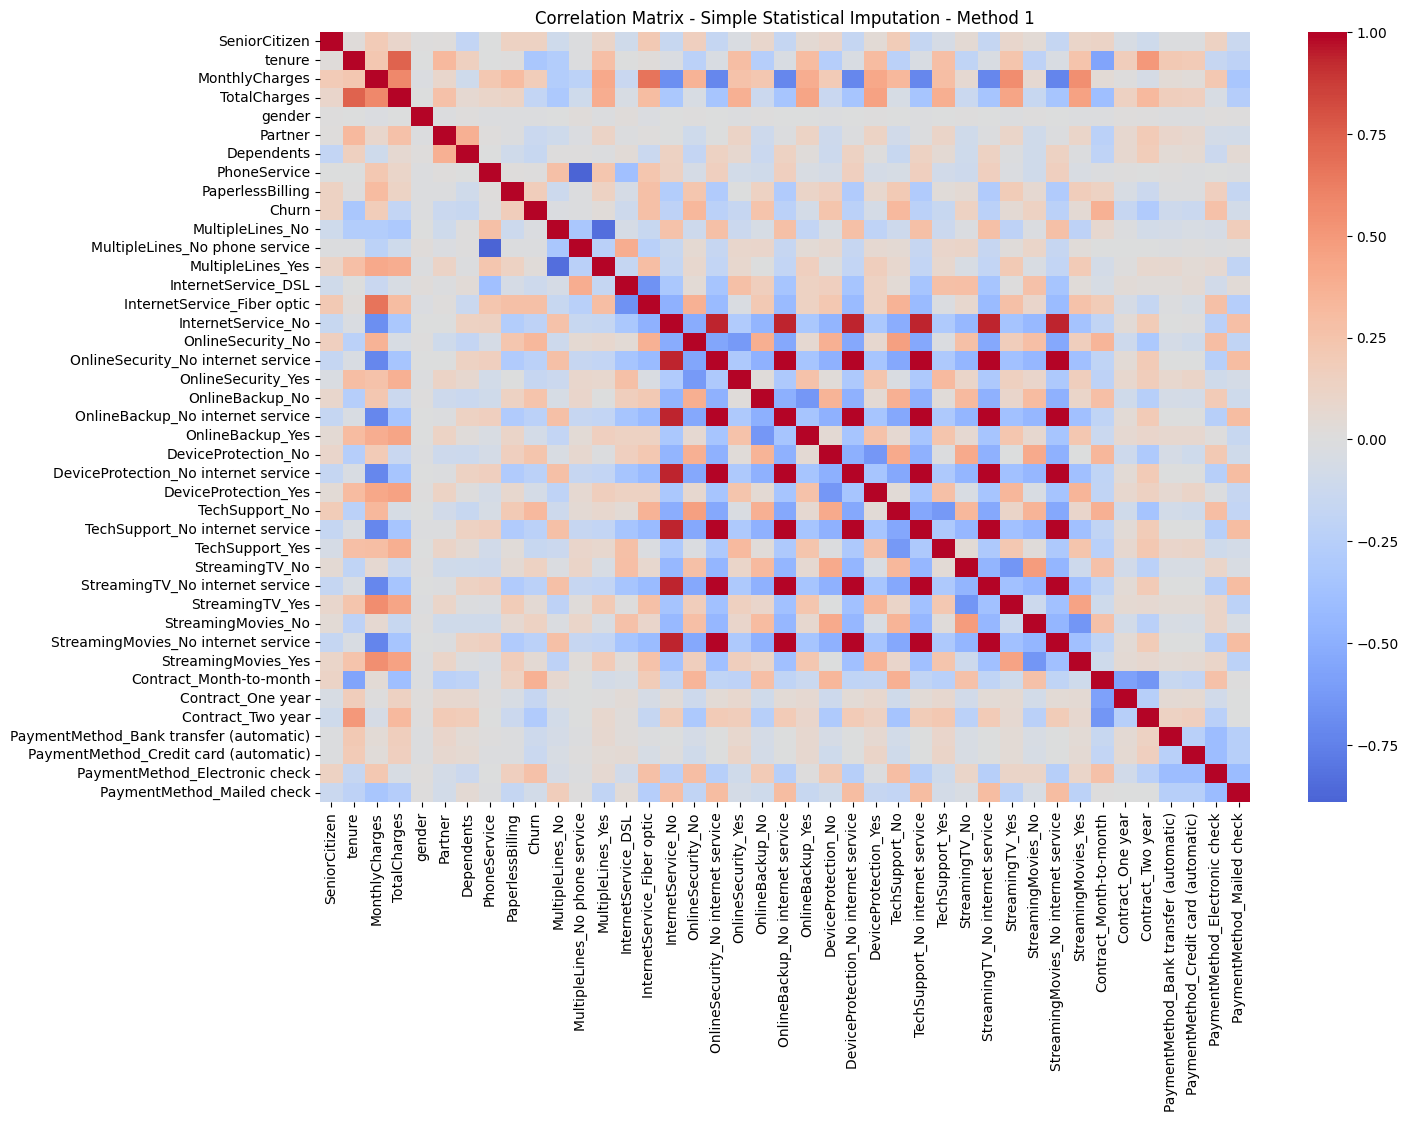

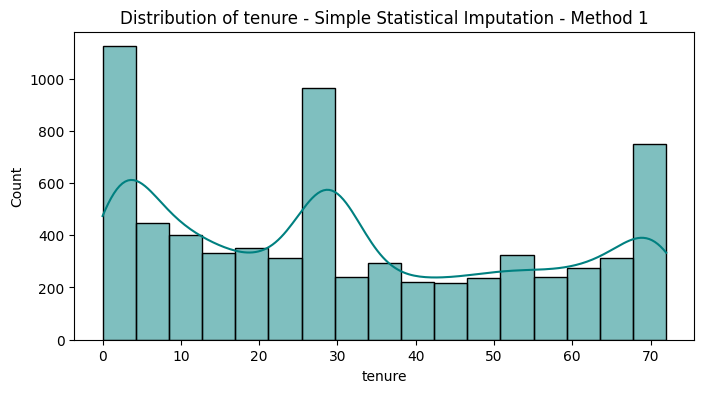

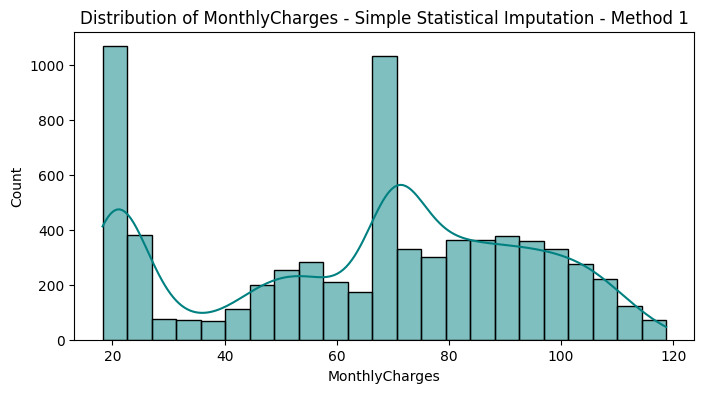

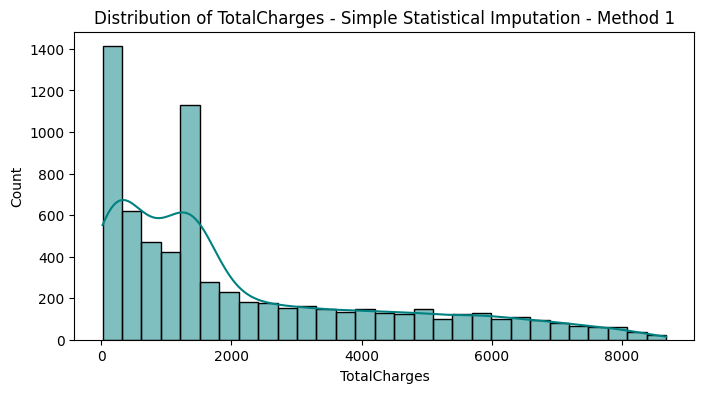

In [125]:
# macierz korelacji
plot_correlation(df_1, "Simple Statistical Imputation - Method 1")

# wykres rozkładu
# kolumny wartościowe do analizy
cols_to_analyze = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in cols_to_analyze:
    plot_distribution(df_1, col, "Simple Statistical Imputation - Method 1")

In [126]:
# warianty standaryzacji

# wariant A - min-max
df_1A = manual_min_max(df_1)
print(df_1A.head())
# wariant B - standaryzacja
df_1B = manual_standardization(df_1)
print(df_1B.head())

✅ Data scaled with min-max method
   SeniorCitizen    tenure  MonthlyCharges  TotalCharges  gender  Partner  \
0            0.0  0.013889        0.115423      0.001275     0.0      1.0   
1            0.0  0.472222        0.517910      0.215867     1.0      0.0   
2            0.0  0.027778        0.354229      0.010310     1.0      0.0   
3            0.0  0.625000        0.239303      0.210241     1.0      0.0   
4            0.0  0.027778        0.521891      0.015330     0.0      0.0   

   Dependents  PhoneService  PaperlessBilling  Churn  ...  StreamingMovies_No  \
0         0.0           0.0               1.0      0  ...                 1.0   
1         0.0           1.0               0.0      0  ...                 1.0   
2         0.0           1.0               1.0      1  ...                 1.0   
3         0.0           0.0               1.0      0  ...                 1.0   
4         0.0           1.0               1.0      1  ...                 1.0   

   StreamingMovi

Random Distributional Imputation

In [127]:
# imputacja

# kopia datasetu
df_copy = df.copy()

# losowanie wartości już występujących
for col in df_copy.columns:
    if df_copy[col].isnull().any():
        # pobieranie istniejących wartości, bez NaN
        valid_values = df_copy[col].dropna()
        # ile jest braków wartości
        num_nulls = df_copy[col].isnull().sum()
        # losowanie wartości
        random_samples = np.random.choice(valid_values, size=num_nulls, replace=True)
        # wstawienie wartości
        df_copy.loc[df_copy[col].isnull(), col] = random_samples

# imputacja danych
df_2_fixed = fix_imputation_logic(df_copy) # zakomentować aby zobaczyć bez poprawki kolumn zależnych

# sprawdzenie
missing_data_2 = df_2_fixed.isna().any().any()
print(f"Is missing data in the dataset: {missing_data_2}")
print(f"Missing data per column:")
print(df_2_fixed.isna().sum())

Is missing data in the dataset: False
Missing data per column:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [128]:
# transformacja
df_2 = transform_data(df_2_fixed)
df_2['SeniorCitizen'] = df_2['SeniorCitizen'].astype('int64')
df_2.info()
print(f"Number of colums after the transformation: {df_2.shape[1]}")

✅ Data encoded
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 41 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7043 non-null   int64  
 1   SeniorCitizen                            7043 non-null   int64  
 2   Partner                                  7043 non-null   int64  
 3   Dependents                               7043 non-null   int64  
 4   tenure                                   7043 non-null   float64
 5   PhoneService                             7043 non-null   int64  
 6   PaperlessBilling                         7043 non-null   int64  
 7   MonthlyCharges                           7043 non-null   float64
 8   TotalCharges                             7043 non-null   float64
 9   Churn                                    7043 non-null   int64  
 10  MultipleLines_No                         704

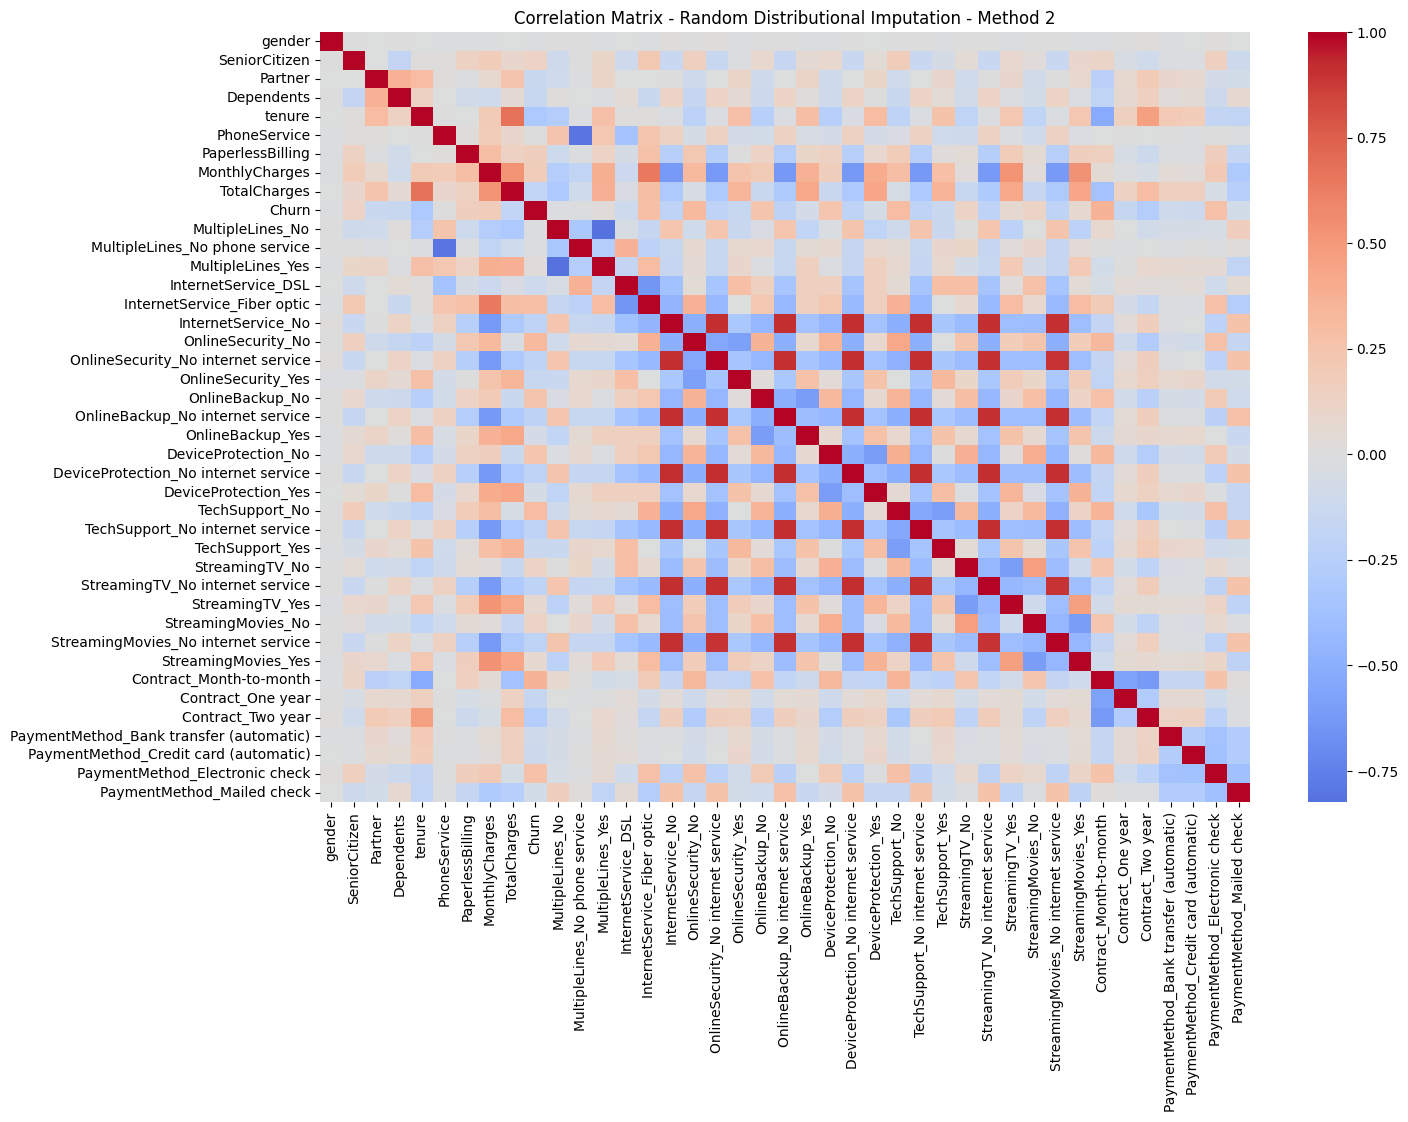

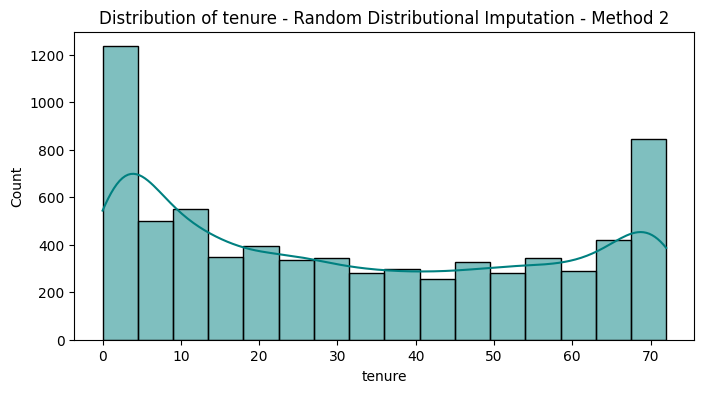

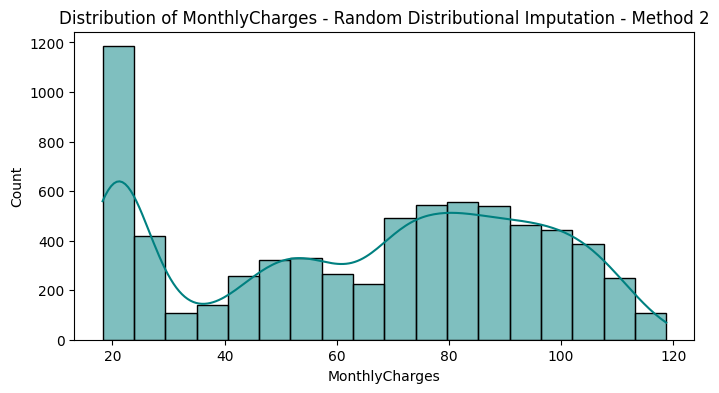

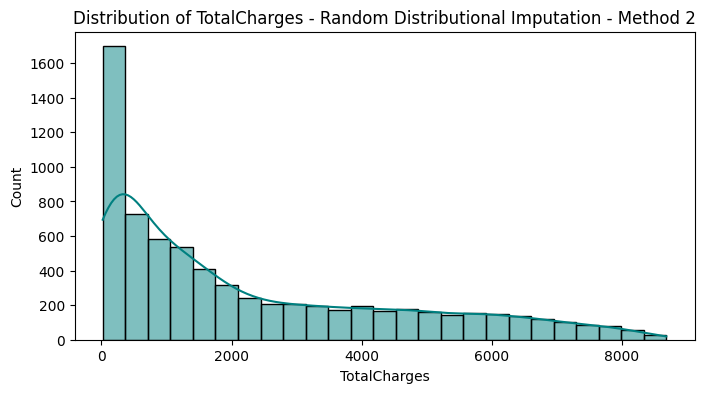

In [129]:
# macierz korelacji
plot_correlation(df_2, "Random Distributional Imputation - Method 2")

# wykres rozkładu
# kolumny wartościowe do analizy
cols_to_analyze = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in cols_to_analyze:
    plot_distribution(df_2, col, "Random Distributional Imputation - Method 2")

In [130]:
# warianty standaryzacji

# wariant A - min-max
df_2A = manual_min_max(df_2)
print(df_2A.head())
# wariant B - standaryzacja
df_2B = manual_standardization(df_2)
print(df_2B.head())

✅ Data scaled with min-max method
   gender  SeniorCitizen  Partner  Dependents    tenure  PhoneService  \
0     0.0            0.0      1.0         0.0  0.013889           0.0   
1     0.0            0.0      0.0         0.0  0.472222           1.0   
2     1.0            0.0      0.0         0.0  0.027778           1.0   
3     1.0            0.0      0.0         0.0  0.625000           0.0   
4     0.0            0.0      0.0         0.0  0.027778           1.0   

   PaperlessBilling  MonthlyCharges  TotalCharges  Churn  ...  \
0               1.0        0.115423      0.001275      0  ...   
1               0.0        0.308458      0.215867      0  ...   
2               1.0        0.354229      0.010310      1  ...   
3               1.0        0.239303      0.210241      0  ...   
4               1.0        0.521891      0.015330      1  ...   

   StreamingMovies_No  StreamingMovies_No internet service  \
0                 1.0                                  0.0   
1           

K-Nearest Neighbors (KNN) Imputation

In [ ]:
from sklearn.impute import KNNImputer

df_copy = df.copy()

# transformacja jako pierwsza w przypadku modelu, korzysta on z liczb 0/1
df_knn_ord, knn_encoder = transform_to_ordinal(df_copy)
# definicja imputera, zgadywanie na podstawie 5 najbliższych sąsiadów
knn_imp = KNNImputer(n_neighbors=5)


C:\Users\MIŁOSZ\AppData\Local\Temp\ipykernel_584276\982381913.py:51: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_t.select_dtypes(include=['object']).columns.tolist()


In [132]:
# imputacja danych
df_3 = apply_imputation(df_knn_ord, knn_imp)
cat_cols = df_copy.select_dtypes(include=['object']).columns.tolist()
temp_values = df_3[cat_cols].values.copy()
decoded_values = knn_encoder.inverse_transform(temp_values)
df_3[cat_cols] = decoded_values
df_3 = fix_imputation_logic(df_3) # zakomentować aby zobaczyć bez poprawki kolumn zależnych
df_3 = transform_data(df_3)

df_3['SeniorCitizen'] = df_3['SeniorCitizen'].astype('int64')
df_3.info()
print(f"Number of colums after the transformation: {df_3.shape[1]}")

# sprawdzenie
missing_data_3 = df_3.isna().any().any()
print(f"Is missing data in the dataset: {missing_data_3}")
print(f"Missing data per column:")
print(df_3.isna().sum())

✅ Missing values filled
✅ Data encoded
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 41 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7043 non-null   int64  
 1   SeniorCitizen                            7043 non-null   int64  
 2   Partner                                  7043 non-null   int64  
 3   Dependents                               7043 non-null   int64  
 4   tenure                                   7043 non-null   float64
 5   PhoneService                             7043 non-null   int64  
 6   PaperlessBilling                         7043 non-null   int64  
 7   MonthlyCharges                           7043 non-null   float64
 8   TotalCharges                             7043 non-null   float64
 9   Churn                                    7043 non-null   int64  
 10  MultipleLines_No    

C:\Users\MIŁOSZ\AppData\Local\Temp\ipykernel_584276\2625669450.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_copy.select_dtypes(include=['object']).columns.tolist()


Is missing data in the dataset: False
Missing data per column:
gender                                     0
SeniorCitizen                              0
Partner                                    0
Dependents                                 0
tenure                                     0
PhoneService                               0
PaperlessBilling                           0
MonthlyCharges                             0
TotalCharges                               0
Churn                                      0
MultipleLines_No                           0
MultipleLines_No phone service             0
MultipleLines_Yes                          0
InternetService_DSL                        0
InternetService_Fiber optic                0
InternetService_No                         0
OnlineSecurity_No                          0
OnlineSecurity_No internet service         0
OnlineSecurity_Yes                         0
OnlineBackup_No                            0
OnlineBackup_No internet service     

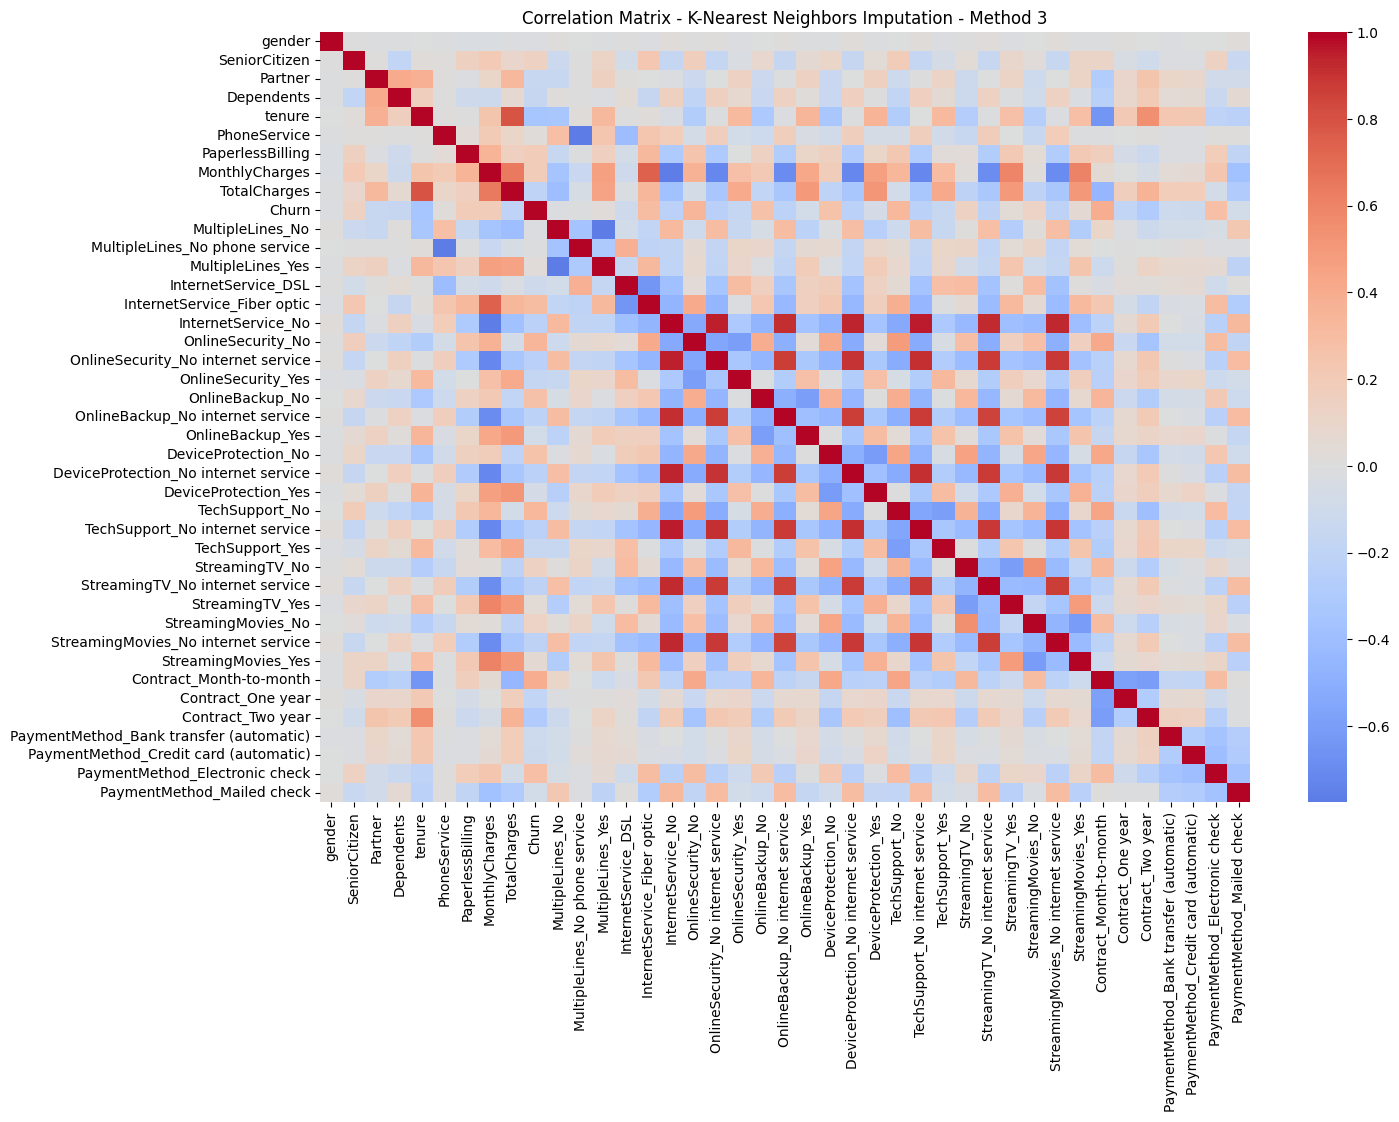

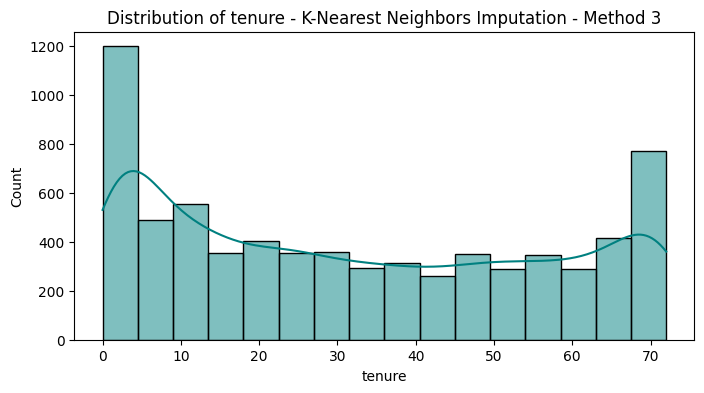

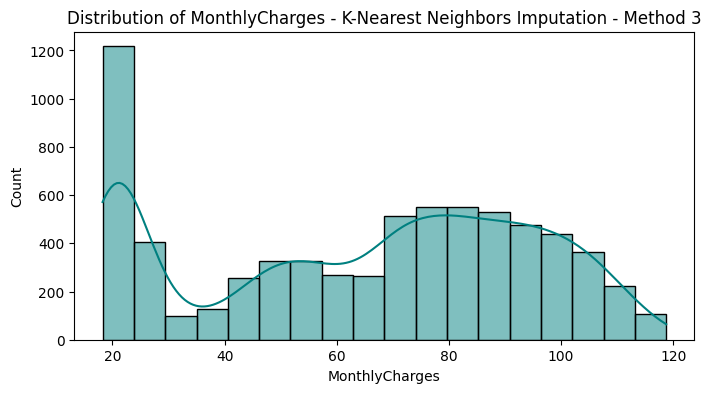

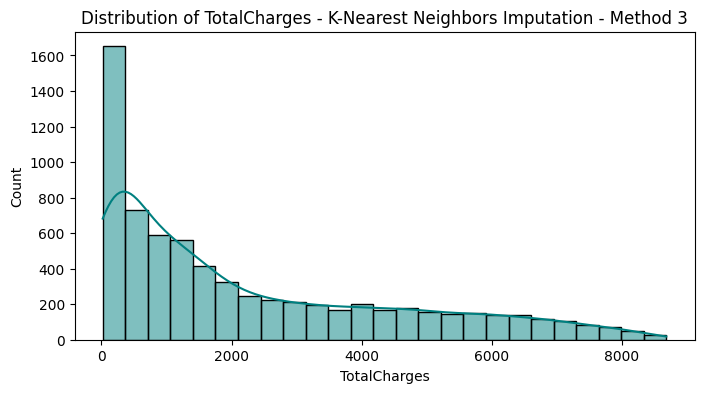

In [133]:
# macierz korelacji
plot_correlation(df_3, "K-Nearest Neighbors Imputation - Method 3")

# wykres rozkładu
# kolumny wartościowe do analizy
cols_to_analyze = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in cols_to_analyze:
    plot_distribution(df_3, col, "K-Nearest Neighbors Imputation - Method 3")

In [134]:
# warianty standaryzacji

# wariant A - min-max
df_3A = manual_min_max(df_3)
print(df_3A.head())
# wariant B - standaryzacja
df_3B = manual_standardization(df_3)
print(df_3B.head())

✅ Data scaled with min-max method
   gender  SeniorCitizen  Partner  Dependents    tenure  PhoneService  \
0     0.0            0.0      1.0         0.0  0.013889           0.0   
1     0.0            0.0      0.0         0.0  0.472222           1.0   
2     1.0            0.0      0.0         0.0  0.027778           1.0   
3     1.0            0.0      0.0         0.0  0.625000           0.0   
4     0.0            0.0      0.0         0.0  0.027778           1.0   

   PaperlessBilling  MonthlyCharges  TotalCharges  Churn  ...  \
0               1.0        0.115423      0.001275      0  ...   
1               0.0        0.240133      0.215867      0  ...   
2               1.0        0.354229      0.010310      1  ...   
3               0.0        0.239303      0.210241      0  ...   
4               1.0        0.521891      0.015330      1  ...   

   StreamingMovies_No  StreamingMovies_No internet service  \
0                 1.0                                  0.0   
1           

Multivariate Iterative Imputation (MICE)

In [135]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

df_copy = df.copy()

# transformacja jako pierwsza w przypadku modelu, korzysta on z liczb 0/1
df_mice_ord, mice_encoder = transform_to_ordinal(df_copy)
# definicja imputera, model max 10 razy poprawi swoje przewidywania
iter_imp = IterativeImputer(max_iter=10, random_state=42)

C:\Users\MIŁOSZ\AppData\Local\Temp\ipykernel_584276\982381913.py:51: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_t.select_dtypes(include=['object']).columns.tolist()


In [136]:
# imputacja danych
df_4 = apply_imputation(df_mice_ord, iter_imp)
cat_cols = df_copy.select_dtypes(include=['object']).columns.tolist()
temp_values = df_4[cat_cols].values.copy()
df_4[cat_cols] = mice_encoder.inverse_transform(temp_values)
df_4 = fix_imputation_logic(df_4) # zakomentować aby zobaczyć bez poprawki kolumn zależnych
df_4 = transform_data(df_4)

df_4['SeniorCitizen'] = df_4['SeniorCitizen'].astype('int64')
df_4.info()
print(f"Number of colums after the transformation: {df_4.shape[1]}")

# sprawdzenie
missing_data_4 = df_4.isna().any().any()
print(f"Is missing data in the dataset: {missing_data_4}")
print(f"Missing data per column:")
print(df_4.isna().sum())

✅ Missing values filled
✅ Data encoded
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 41 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7043 non-null   int64  
 1   SeniorCitizen                            7043 non-null   int64  
 2   Partner                                  7043 non-null   int64  
 3   Dependents                               7043 non-null   int64  
 4   tenure                                   7043 non-null   float64
 5   PhoneService                             7043 non-null   int64  
 6   PaperlessBilling                         7043 non-null   int64  
 7   MonthlyCharges                           7043 non-null   float64
 8   TotalCharges                             7043 non-null   float64
 9   Churn                                    7043 non-null   int64  
 10  MultipleLines_No    

c:\Users\MIŁOSZ\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
C:\Users\MIŁOSZ\AppData\Local\Temp\ipykernel_584276\1617817768.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_copy.select_dtypes(include=['object']).columns.tolist()


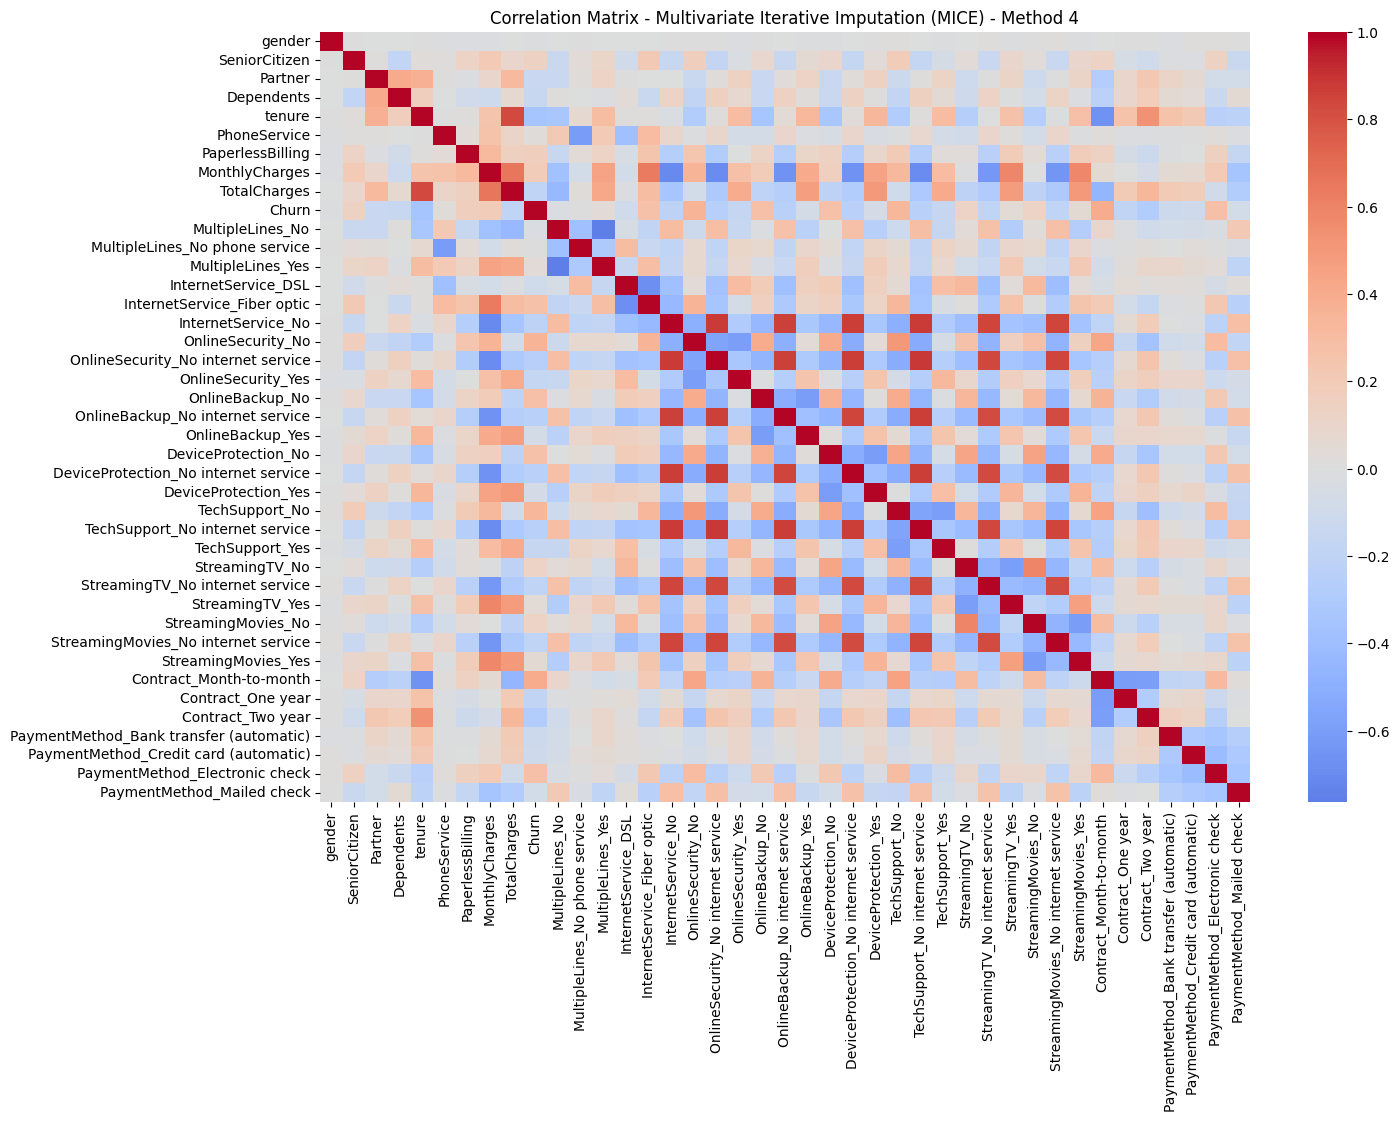

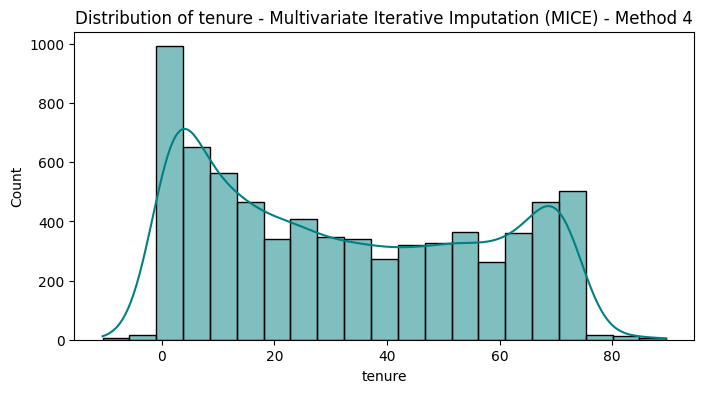

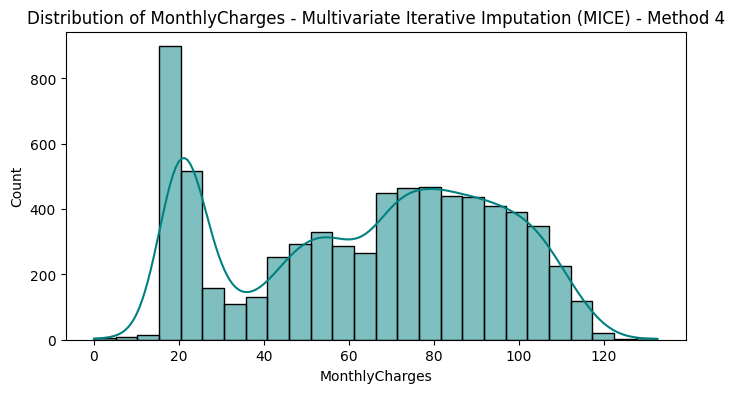

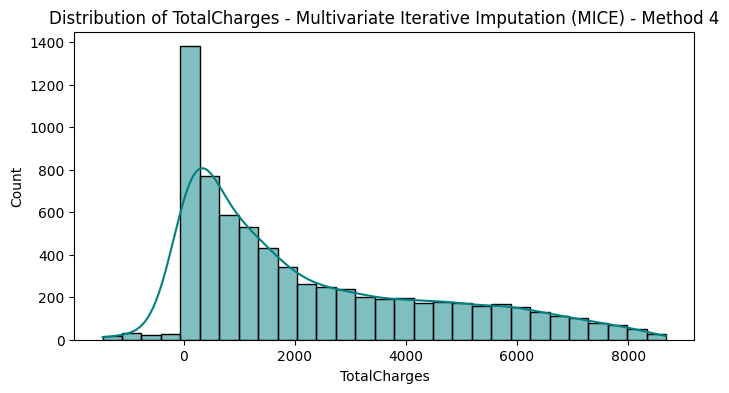

In [137]:
# macierz korelacji
plot_correlation(df_4, "Multivariate Iterative Imputation (MICE) - Method 4")

# wykres rozkładu
# kolumny wartościowe do analizy
cols_to_analyze = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in cols_to_analyze:
    plot_distribution(df_4, col, "Multivariate Iterative Imputation (MICE) - Method 4")

In [138]:
# warianty standaryzacji

# wariant A - min-max
df_4A = manual_min_max(df_4)
print(df_4A.head())
# wariant B - standaryzacja
df_4B = manual_standardization(df_4)
print(df_4B.head())

✅ Data scaled with min-max method
   gender  SeniorCitizen  Partner  Dependents    tenure  PhoneService  \
0     0.0            0.0      1.0         0.0  0.114872           0.0   
1     0.0            0.0      0.0         0.0  0.444580           1.0   
2     1.0            0.0      0.0         0.0  0.124863           1.0   
3     1.0            0.0      0.0         0.0  0.554482           0.0   
4     0.0            0.0      0.0         0.0  0.124863           1.0   

   PaperlessBilling  MonthlyCharges  TotalCharges  Churn  ...  \
0               1.0        0.224896      0.146560      0  ...   
1               0.0        0.388748      0.329935      0  ...   
2               1.0        0.405807      0.154281      1  ...   
3               0.0        0.318743      0.325127      0  ...   
4               1.0        0.532821      0.158570      1  ...   

   StreamingMovies_No  StreamingMovies_No internet service  \
0                 1.0                                  0.0   
1           

Consistency Validation Test

In [139]:
# definicja funkcji sprawdzającej błędy logiczne przy imputacji danych

def evaluate_imputation_quality(df_test, method_name):
    # rekordy bez internetu - kolumny od której zależą inne
    no_internet = (df_test['InternetService_No'] == 1)
    df_no_int = df_test[no_internet]

    has_internet = (df_test['InternetService_No'] == 0)
    df_has_int = df_test[has_internet]
    
    # sprawdzane kolumny
    services_yes = [
        'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 
        'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes'
    ]
    
    services_no = [
        'OnlineSecurity_No', 'OnlineBackup_No', 'DeviceProtection_No', 
        'TechSupport_No', 'StreamingTV_No', 'StreamingMovies_No'
    ]

    services_no_internet_service = [
        'OnlineSecurity_No internet service', 'OnlineBackup_No internet service',
        'DeviceProtection_No internet service', 'TechSupport_No internet service',
        'StreamingTV_No internet service', 'StreamingMovies_No internet service'
    ]
    
    total_customers_no_int = len(df_no_int)
    total_customers_has_int = len(df_has_int)
    errors_yes = 0
    errors_no = 0
    errors_no_internet_service_mismatch = 0

    if total_customers_no_int > 0:
        # wartość TAK pomimo braku internetu
        for col in services_yes:
            if col in df_no_int.columns:
                errors_yes += (df_no_int[col] == 1).sum()
        # wartość NIE pomimo braku internetu
        for col in services_no:
            if col in df_no_int.columns:
                errors_no += (df_no_int[col] == 1).sum()

    if total_customers_has_int > 0:
        # wartość BRAK SERWISU INTERNETOWEGO pomimo posiadania go
        for col in services_no_internet_service:
            if col in df_has_int.columns:
                errors_no_internet_service_mismatch += (df_has_int[col] == 1).sum()
    
    total_logical_errors = errors_yes + errors_no + errors_no_internet_service_mismatch

    # 12 kolumn dla braku internetu, 6 dla posiadania go
    possible_slots = (total_customers_no_int * 12) + (total_customers_has_int * 6)
    
    error_rate_total = (total_logical_errors / possible_slots) * 100 if possible_slots > 0 else 0

    # BŁĘDNE REKORDY
    # rekord błedny jeśli choć 1 rekord ma złą wartość

    bad_records_no_int = 0
    bad_records_has_int = 0

    if total_customers_no_int > 0:
        bad_records_no_int = (df_no_int[services_yes + services_no] == 1).any(axis=1).sum()

    if total_customers_has_int > 0:
        bad_records_has_int = (df_has_int[services_no_internet_service] == 1).any(axis=1).sum()

    total_bad_records = bad_records_no_int + bad_records_has_int
    total_samples = len(df_test)
    record_error_rate = (total_bad_records / total_samples) * 100

    # współczynniki błędu
    print(f"--- Imputation quality: {method_name} ---")
    print(f"Clients without internet: {total_customers_no_int} | Clients with internet: {total_customers_has_int}")
    print(f"Errors in 'Yes' columns: {errors_yes}")
    print(f"Errors in 'No' columns: {errors_no}")
    print(f"Errors - 'NoInternetService' columns: {errors_no_internet_service_mismatch}")
    print(f"Total logical inconsistencies: {total_logical_errors}")
    print(f"OVERALL Value Inconsistency Rate: {error_rate_total:.2f}%")
    print(f"Total Corrupted Records: {total_bad_records} / {total_samples}")
    print(f"OVERALL Record Error Rate: {record_error_rate:.2f}%")
    print("-" * 50)
    
    return {
        'method': method_name,
        'errors_yes': errors_yes,
        'errors_no': errors_no,
        'errors_no_internet_service_mismatch': errors_no_internet_service_mismatch,
        'total_errors': total_logical_errors,
        'rate': error_rate_total
    }

In [141]:
# porównanie dla każdej metody oraz oryginału

# kopia oryginału dla porównania
df_original_completed = df_completed.copy()
df_original_encoded = transform_data(df_original_completed)

original_results = evaluate_imputation_quality(df_original_encoded, "Original Dataset")
m1_results = evaluate_imputation_quality(df_1, "Simple Statistical Imputation")
m2_results = evaluate_imputation_quality(df_2, "Random Distributional Imputation")
m3_results = evaluate_imputation_quality(df_3, "K-Nearest Neighbors (KNN) Imputation")
m4_results = evaluate_imputation_quality(df_4, "Multivariate Iterative Imputation (MICE)")

✅ Data encoded
--- Imputation quality: Original Dataset ---
Clients without internet: 1526 | Clients with internet: 5517
Errors in 'Yes' columns: 0
Errors in 'No' columns: 0
Errors - 'NoInternetService' columns: 0
Total logical inconsistencies: 0
OVERALL Value Inconsistency Rate: 0.00%
Total Corrupted Records: 0 / 7043
OVERALL Record Error Rate: 0.00%
--------------------------------------------------
--- Imputation quality: Simple Statistical Imputation ---
Clients without internet: 1365 | Clients with internet: 5678
Errors in 'Yes' columns: 0
Errors in 'No' columns: 0
Errors - 'NoInternetService' columns: 877
Total logical inconsistencies: 877
OVERALL Value Inconsistency Rate: 1.74%
Total Corrupted Records: 161 / 7043
OVERALL Record Error Rate: 2.29%
--------------------------------------------------
--- Imputation quality: Random Distributional Imputation ---
Clients without internet: 1522 | Clients with internet: 5521
Errors in 'Yes' columns: 0
Errors in 'No' columns: 0
Errors - 'N